In [1]:
import os

import numpy as np
import pandas as pd
from features import *
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [2]:
def complete_dict(list_dataframe, clean):
    if clean:
        path = "../Data/train/with_label/clean"
    else:
        path = "../Data/train/with_label/dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if clean:
                dict['class'] = 'clean'
            else:
                dict['class'] = 'dirty'
            list_dataframe.append(dict)

In [3]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 0)

    return list_dataframe

In [4]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']].astype(float)
df[['image_width', 'image_height', 'contraste_maximal']] = df[['image_width', 'image_height', 'contraste_maximal']].astype(int)

In [5]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,saturation,hist_rgb,hist_luminance,edge_density,edge_density_V2,class
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,56.431538,29.08,"{""red"": [110, 28, 27, 20, 38, 36, 58, 58, 73, ...","[1, 33, 27, 15, 22, 21, 28, 35, 37, 45, 41, 61...",0.1123,52889.0,clean
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.839565,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,23010.0,clean
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285750,44.79,"{""red"": [52, 27, 31, 31, 43, 41, 58, 51, 60, 5...","[3, 13, 10, 18, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,52980.0,clean
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,44.082533,17.20,"{""red"": [8, 1, 3, 7, 12, 6, 14, 12, 23, 23, 25...","[0, 4, 2, 4, 2, 3, 9, 13, 15, 20, 22, 30, 41, ...",0.0677,37542.0,clean
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,48.528542,40.16,"{""red"": [65, 40, 38, 86, 154, 289, 469, 834, 1...","[11, 44, 69, 108, 240, 408, 844, 1573, 2059, 2...",0.0330,112613.0,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,train_no_label_img_539.jpeg,517.28,1918,814,92.01,93.92,92.50,93.18703,253,46.647750,56.45,"{""red"": [2, 6, 3, 14, 14, 28, 35, 55, 76, 127,...","[0, 0, 1, 1, 3, 0, 3, 8, 25, 24, 51, 69, 85, 1...",0.0674,211168.0,dirty
128,train_no_label_img_541.jpeg,79.12,600,450,86.47,82.63,76.20,83.04514,250,51.187696,51.02,"{""red"": [0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 8, 9, 2...","[0, 0, 0, 0, 0, 1, 1, 3, 1, 2, 7, 13, 25, 44, ...",0.1270,51143.0,dirty
129,train_no_label_img_545.jpeg,36.78,600,450,121.41,114.85,106.24,115.82990,254,57.360416,41.45,"{""red"": [5, 2, 0, 1, 2, 6, 3, 2, 8, 3, 6, 12, ...","[0, 4, 1, 1, 5, 8, 3, 8, 9, 18, 12, 18, 19, 18...",0.1321,48437.0,dirty
130,train_no_label_img_546.jpeg,25.79,600,337,166.24,164.47,160.61,164.55919,245,51.607650,22.30,"{""red"": [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, ...",0.0479,17387.0,dirty


Get the max and min of every color of the histogramme

In [6]:
df['max_r'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['max_g'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['max_b'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

df['min_r'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['min_g'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['min_b'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

Get index of max

In [7]:
df['index_max_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['max_r']), axis =1)
df['index_max_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['max_g']), axis =1)
df['index_max_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['max_b']), axis =1)

df['index_min_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['min_r']), axis =1)
df['index_min_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['min_g']), axis =1)
df['index_min_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['min_b']), axis =1)

Get the max and min of the luminance

In [8]:
df['max_lum'] = df.apply(lambda row : max(ast.literal_eval(row['hist_luminance'])), axis =1)
df['min_lum'] = df.apply(lambda row : min(ast.literal_eval(row['hist_luminance'])), axis =1)

In [9]:
df['index_max_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['max_lum']), axis =1)
df['index_min_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['min_lum']), axis =1)

Get the difference and sum of the averages

In [10]:
df['sum_avg'] = df['mean_r'] + df['mean_g'] + df['mean_b']
df['sum_diff_avg'] = abs(df['mean_r'] - df['mean_g']) + abs(df['mean_r'] - df['mean_b']) + abs(df['mean_b'] - df['mean_g'])

In [11]:
def get_whites_from_hist(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])

    diff =abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum((mean - diff)>0)
    return whites

In [12]:
df['quantity of whites'] = df.apply(lambda row : get_whites_from_hist(ast.literal_eval(row['hist_rgb'])), axis =1)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [14]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,...,index_min_r,index_min_g,index_min_b,max_lum,min_lum,index_max_lum,index_min_lum,sum_avg,sum_diff_avg,quantity of whites
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,56.431538,...,253,0,1,9653,1,119,0,371.66,10.66,201
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.839565,...,2,1,1,6255,0,255,0,325.82,18.18,120
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285750,...,241,232,244,5644,1,147,233,364.24,4.84,57
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,44.082533,...,1,1,254,10928,0,192,0,392.60,5.18,209
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,48.528542,...,2,1,1,39961,11,80,0,322.48,19.92,76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,train_no_label_img_539.jpeg,517.28,1918,814,92.01,93.92,92.50,93.18703,253,46.647750,...,0,0,1,22315,0,57,0,278.43,3.82,187
128,train_no_label_img_541.jpeg,79.12,600,450,86.47,82.63,76.20,83.04514,250,51.187696,...,0,1,2,6773,0,45,0,245.30,20.54,181
129,train_no_label_img_545.jpeg,36.78,600,450,121.41,114.85,106.24,115.82990,254,57.360416,...,2,4,1,5909,0,72,0,342.50,30.34,139
130,train_no_label_img_546.jpeg,25.79,600,337,166.24,164.47,160.61,164.55919,245,51.607650,...,0,0,0,4315,0,212,0,491.32,11.26,127


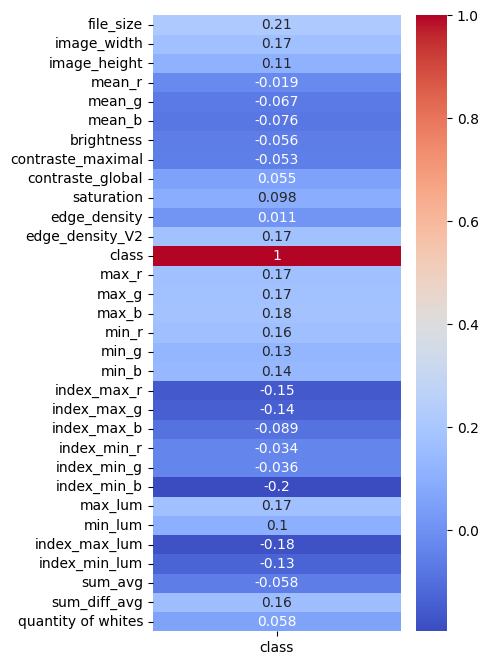

In [15]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(4, 8))
sns.heatmap(corr_matrix[['class']], cmap='coolwarm', annot = True)
plt.show()

We tested the correlation matrix with the initial 40 images and the correlation matrix with additional images classified by hand (132 images in total)

Test with 20 images from each side, we keep >0.15 and <-0.15
- file_size
- image_width
- image_height
- mean_r
- mean_g
- brightness
- contraste_global
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_avg
- quantities_of_whites

test with 66 images from each side, we keep >0.1 and <0.1
- file_size
- image_width
- image_height
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- index_min_b
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_diff_avg

We can see that some values are still here and some changed. We will do some tests and check if some values should not be kept. In the mean time, we will keep the variables from the test with the biggest number

In [16]:
df_clean = df[df['class'] == 0]
df_dirty = df[df['class'] == 1]